# Hybrid locomotion controller

This tutorial runs the v2 hybrid walking controller on mixed terrain. The controller combines tripod CPG stepping with local retraction and stumbling corrections, then renders the rollout directly in the notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from tqdm import trange

from flygym import Simulation
from flygym.anatomy import BodySegment, ContactBodiesPreset
from flygym.compose import MixedTerrainWorld
from flygym.examples.locomotion import (
    HybridController,
    LocomotionAction,
    PreprogrammedSteps,
    apply_locomotion_action,
    make_locomotion_fly,
)
from flygym.utils.math import Rotation3D


output_dir = Path("outputs/hybrid_controller")
output_dir.mkdir(parents=True, exist_ok=True)

In [2]:
fly = make_locomotion_fly(
    name="hybrid_demo",
    add_adhesion=True,
    colorize=True,
)
body_cam = fly.add_tracking_camera(
    name="body_cam",
    pos_offset=(0.0, -8.0, 1.2),
    rotation=Rotation3D("euler", (1.57, 0.0, 0.0)),
    fovy=35.0,
)

world = MixedTerrainWorld()
world.add_fly(
    fly,
    [0, 0, 1.2],
    Rotation3D("quat", [1, 0, 0, 0]),
    bodysegs_with_ground_contact=ContactBodiesPreset.TIBIA_TARSUS_ONLY,
    add_ground_contact_sensors=False,
)

sim = Simulation(world)
renderer = sim.set_renderer(
    [body_cam],
    camera_res=(240, 320),
    playback_speed=0.1,
    output_fps=25,
)

In [3]:
preprogrammed_steps = PreprogrammedSteps()
dof_order = fly.get_actuated_jointdofs_order("position")
controller = HybridController(
    timestep=sim.timestep,
    preprogrammed_steps=preprogrammed_steps,
    output_dof_order=dof_order,
)

print("Actuated DoFs:", len(dof_order))
print("Simulation timestep:", sim.timestep)
print("Controller CPG frequency (Hz):", float(controller.cpg_network.intrinsic_freqs[0]))

Actuated DoFs: 42
Simulation timestep: 0.0001
Controller CPG frequency (Hz): 12.0


In [4]:
sim.reset()
controller.reset(seed=0)

initial_action = LocomotionAction(
    joint_angles=preprogrammed_steps.default_pose_by_dof_order(dof_order),
    adhesion_onoff=np.ones(6, dtype=bool),
)
apply_locomotion_action(sim, fly.name, initial_action)
sim.warmup()

In [5]:
run_time = 0.5
nsteps_sim = int(run_time / sim.timestep)
time_grid = np.arange(nsteps_sim) * sim.timestep

thorax_idx = fly.get_bodysegs_order().index(BodySegment("c_thorax"))
thorax_positions = np.full((nsteps_sim, 3), np.nan, dtype=np.float32)
adhesion_onoff = np.zeros((nsteps_sim, 6), dtype=bool)
net_corrections = np.full((nsteps_sim, 6), np.nan, dtype=np.float32)

for step_idx in trange(nsteps_sim, desc="Running hybrid controller"):
    action = controller.step(sim, fly.name)
    apply_locomotion_action(sim, fly.name, action)
    sim.step_with_profile()

    thorax_positions[step_idx] = sim.get_body_positions(fly.name)[thorax_idx]
    adhesion_onoff[step_idx] = action.adhesion_onoff
    net_corrections[step_idx] = controller.last_info["net_corrections"]

    sim.render_as_needed_with_profile()

print("Rendered frames:", len(renderer.frames[body_cam.full_identifier]))
print(
    "Thorax forward displacement:",
    f"{thorax_positions[-1, 0] - thorax_positions[0, 0]:.2f} mm",
)
sim.print_performance_report()

Running hybrid controller: 100%|██████████| 5000/5000 [00:07<00:00, 636.13it/s]

Rendered frames: 123
Thorax forward displacement: 4.09 mm
PERFORMANCE PROFILE


Stage,Time/step (us),Percent (%),Throughput (iters/s),Throughput x realtime
Physics simulation advancement,310,32,3229,0.32
Rendering*,662,68,1511,0.15
TOTAL,971,100,1029,0.10


* Note: 123 frames were rendered out of 5000 steps. Therefore, rendering time per image is 26898 us.


In [6]:
sim.renderer.show_in_notebook()
sim.renderer.save_video(output_dir / "hybrid_controller_mixed_terrain.mp4")

hybrid_demo/body_cam This browser does not support the video tag.


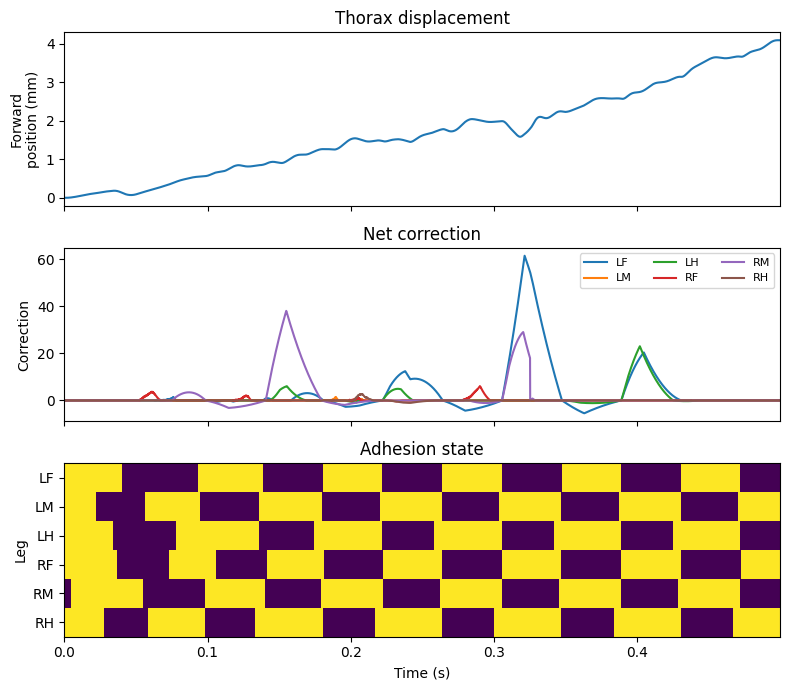

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(8, 7), tight_layout=True, sharex=True)

axes[0].plot(time_grid, thorax_positions[:, 0] - thorax_positions[0, 0])
axes[0].set_ylabel("Forward\nposition (mm)")
axes[0].set_title("Thorax displacement")

for leg_idx, leg in enumerate(preprogrammed_steps.legs):
    axes[1].plot(time_grid, net_corrections[:, leg_idx], label=leg.upper())
axes[1].set_ylabel("Correction")
axes[1].set_title("Net correction")
axes[1].legend(ncols=3, fontsize=8)

axes[2].imshow(
    adhesion_onoff.T,
    aspect="auto",
    interpolation="nearest",
    extent=(time_grid[0], time_grid[-1], 5.5, -0.5),
)
axes[2].set_yticks(np.arange(6))
axes[2].set_yticklabels([leg.upper() for leg in preprogrammed_steps.legs])
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Leg")
axes[2].set_title("Adhesion state")

fig.savefig(output_dir / "hybrid_controller_diagnostics.png")